In [1]:
import os
import os.path as osp
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.utils as vutils
from torch.utils.data import DataLoader


from src.datasets import DatasetBuilder
import albumentations as A

from src.utils import seed_everything, get_config, load_model_weights
from src.cf_methods.c3lt import models 


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
I0000 00:00:1775584116.029262    2946 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed_everything()

plt.style.use('seaborn-v0_8-darkgrid')
params = {"text.color" : "black"}
plt.rcParams.update(params)

## Load data

In [3]:
repo_path = r'/teamspace/studios/this_studio/CF-Robustness-Benchmark'  
config_path = osp.join(repo_path, r'configs/train_classifier_derma_optimized.yaml')

config = get_config(config_path)

BATCH_SIZE = config.batch_size
img_size = config.data.img_size

In [4]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

# This maps [0, 255] → [-1, 1] exactly, matching Tanh() output range
gan_mean = [0.5, 0.5, 0.5]
gan_std = [0.5, 0.5, 0.5]

train_transform = A.Compose([
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=gan_mean, std=gan_std, max_pixel_value=255.0),
])

val_transform = A.Compose([
    A.Normalize(mean=gan_mean, std=gan_std, max_pixel_value=255.0),
])

train_loader.dataset.transform = train_transform
val_loader.dataset.transform = val_transform
test_loader.dataset.transform = val_transform

In [5]:
latent_dim = 100
ngf = 64 # Size of feature maps in generator
ndf = 64 # Size of feature maps in discriminator
nc = 3 # Number of channels
beta1 = 0.5 # Beta1 hyperparameter for Adam optimizers
lr = 0.0002 # Learning rate for optimizers

# Derived constants (single source of truth)
NUM_CLASSES = config.data.num_classes
DEVICE = config.accelerator if torch.cuda.is_available() else 'cpu'
TASK = 'binary' if NUM_CLASSES == 2 else 'multiclass'

print(f"Device: {DEVICE} | Classes: {NUM_CLASSES} | Task: {TASK}")

Device: cuda | Classes: 4 | Task: multiclass


In [6]:
from torch.utils.data import WeightedRandomSampler

def make_balanced_sampler(labels, num_classes):
    """
    Build a sampler that draws each class with equal probability.
    
    Args:
        labels: 1D array of integer class labels for every sample in the dataset.
        num_classes: total number of classes.
    
    Returns:
        WeightedRandomSampler instance (pass to DataLoader's `sampler` arg).
    """
    class_counts = np.bincount(labels, minlength=num_classes)
    
    # Weight per sample = 1 / (count of that sample's class)
    # So if melanocytic nevi has 4528 samples, each one gets weight 1/4528
    # And if basal cell carcinoma has 239 samples, each gets weight 1/239
    # This makes the expected number of draws per class equal across one epoch
    sample_weights = 1.0 / class_counts[labels]
    sample_weights = torch.from_numpy(sample_weights).double()
    
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(labels),  # epoch length stays the same
        replacement=True,         # minority samples get drawn multiple times
    )

train_labels = ds_builder.train_dataset.data.labels.ravel()
balanced_sampler = make_balanced_sampler(train_labels, NUM_CLASSES)

# Replace shuffle=True with sampler — they're mutually exclusive
train_loader = DataLoader(
    ds_builder.train_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
)

train_loader.dataset.transform = train_transform


torch.Size([5, 3, 64, 64])


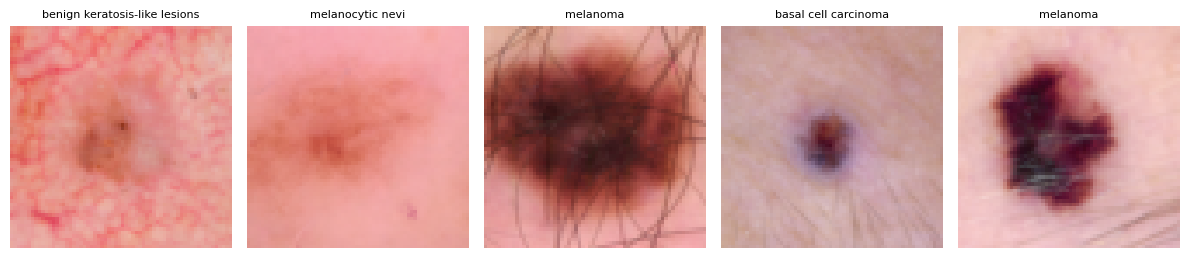

In [7]:
def denormalize(img_tensor, mean, std):
    """Reverse ImageNet normalization for visualization. Input: (C, H, W) tensor."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(12, 4))

sample_batch = next(iter(train_loader))
images, labels = sample_batch[0][:n_samples], sample_batch[1][:n_samples]
print(images.shape)

for i in range(n_samples):
    # display_img = images[i].permute(1, 2, 0).numpy()
    display_img = denormalize(images[i], mean=gan_mean, std=gan_std).permute(1, 2, 0).numpy()
    axs[i].imshow(display_img)
    axs[i].set_title(class_names[labels[i].item()], fontsize=8)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

## Build DCGAN object  

In [19]:
class Generator(nn.Module):
    """
    Generator for DermaMNIST (64x64, 3-channel RGB images).
    
    Changes from MNIST version:
    - nc=3 (RGB instead of grayscale)
    - Added one more ConvTranspose2d layer to reach 64x64 output
    - Adjusted kernel/stride/padding to produce exact 64x64 spatial dims
    - ngf=64 retained (sufficient for 64x64 RGB)
    """
    def __init__(self, latent_dim, ngpu=1, nc=3, ngf=64):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z (latent_dim x 1 x 1)
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size: (ngf*8) x 4 x 4
 
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size: (ngf*4) x 8 x 8
 
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size: (ngf*2) x 16 x 16
 
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size: (ngf) x 32 x 32
 
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
            # output size: (nc) x 64 x 64
        )
 
    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output
 
 
class Discriminator(nn.Module):
    """
    Discriminator for DermaMNIST (64x64, 3-channel RGB images).
    
    Changes from MNIST version:
    - nc=3 (RGB instead of grayscale)
    - Added one more Conv2d layer to handle 64x64 → 1x1 spatial reduction
    - This is the standard DCGAN discriminator for 64x64 images
    """
    def __init__(self, ngpu=1, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (ndf) x 32 x 32
 
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (ndf*2) x 16 x 16
 
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (ndf*4) x 8 x 8
 
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: (ndf*8) x 4 x 4
 
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
            # output size: 1 x 1 x 1
        )
 
    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output.view(-1, 1).squeeze(1)

In [20]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [21]:
gen = Generator(latent_dim=latent_dim, ngf=ngf, nc=nc).to(DEVICE)
discr = Discriminator(ndf=ndf, nc=nc).to(DEVICE)

gen.apply(weights_init);
discr.apply(weights_init);

gen.train();
discr.train();

In [31]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(BATCH_SIZE, latent_dim, 1, 1, device=DEVICE)
 
real_label = 0.9   # label smoothing to prevent D from overfitting # 1
fake_label = 0.0

# Setup Adam optimizers for both G and D
optimizerG = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = torch.optim.Adam(discr.parameters(), lr=lr, betas=(beta1, 0.999))

In [32]:
save_dir = osp.join(repo_path,  r'src/cf_methods/c3lt/weights')
# Directory for checkpoints
os.makedirs(save_dir, exist_ok=True)

In [33]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0
num_epochs = 100


print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(train_loader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        discr.zero_grad()
        # Format batch
        real_cpu = data[0].to(DEVICE)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=DEVICE)
        # Forward pass real batch through D
        output = discr(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, z, 1, 1, device=DEVICE)
        # Generate fake image batch with G
        fake = gen(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = discr(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        gen.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = discr(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # ---------------------------------------------------
        # Logging
        # ---------------------------------------------------
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(train_loader)}]\t'
                  f'Loss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}\t'
                  f'D(x): {D_x:.4f}\tD(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')
 
        G_losses.append(errG.item())
        D_losses.append(errD.item())
 
        # Save sample grids
        if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(train_loader) - 1)):
            with torch.no_grad():
                fake_samples = gen(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake_samples, padding=2, normalize=True))
 
        iters += 1
 
    # ---------------------------------------------------
    # Checkpoint every 20 epochs
    # ---------------------------------------------------
    if (epoch + 1) % 20 == 0:
        torch.save(gen.state_dict(), osp.join(save_dir, 'derma', f"gen_epoch_{epoch+1}.pth"))
        torch.save(discr.state_dict(), osp.join(save_dir, 'derma', f"discr_epoch_{epoch+1}.pth"))
        print(f"  >> Checkpoint saved at epoch {epoch+1}")
 
print("Training complete.")

Starting Training Loop...
[0/100][0/413]	Loss_D: 1.1255	Loss_G: 8.3529	D(x): 0.7967	D(G(z)): 0.4452 / 0.0002
[0/100][50/413]	Loss_D: 0.5050	Loss_G: 7.2956	D(x): 0.9150	D(G(z)): 0.0425 / 0.0003
[0/100][100/413]	Loss_D: 0.4165	Loss_G: 8.6370	D(x): 0.8825	D(G(z)): 0.0523 / 0.0001
[0/100][150/413]	Loss_D: 0.9254	Loss_G: 0.5325	D(x): 0.4960	D(G(z)): 0.0131 / 0.6584
[0/100][200/413]	Loss_D: 1.6718	Loss_G: 0.9503	D(x): 0.2549	D(G(z)): 0.0155 / 0.4423
[0/100][250/413]	Loss_D: 0.3972	Loss_G: 3.9787	D(x): 0.8431	D(G(z)): 0.0296 / 0.0149
[0/100][300/413]	Loss_D: 0.4887	Loss_G: 7.7038	D(x): 0.7098	D(G(z)): 0.0010 / 0.0003
[0/100][350/413]	Loss_D: 0.4610	Loss_G: 3.4557	D(x): 0.7711	D(G(z)): 0.0503 / 0.0286
[0/100][400/413]	Loss_D: 0.5930	Loss_G: 4.7312	D(x): 0.9427	D(G(z)): 0.2004 / 0.0057
[1/100][0/413]	Loss_D: 1.0077	Loss_G: 3.1184	D(x): 0.9318	D(G(z)): 0.3763 / 0.0521
[1/100][50/413]	Loss_D: 0.4922	Loss_G: 3.1055	D(x): 0.8535	D(G(z)): 0.0927 / 0.0426
[1/100][100/413]	Loss_D: 0.8732	Loss_G: 4.910

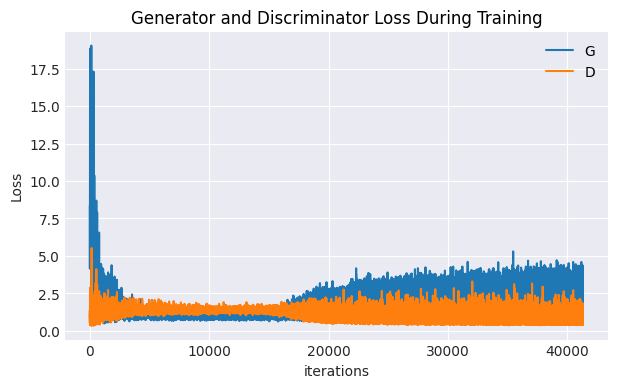

In [34]:
plt.figure(figsize=(7,4))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

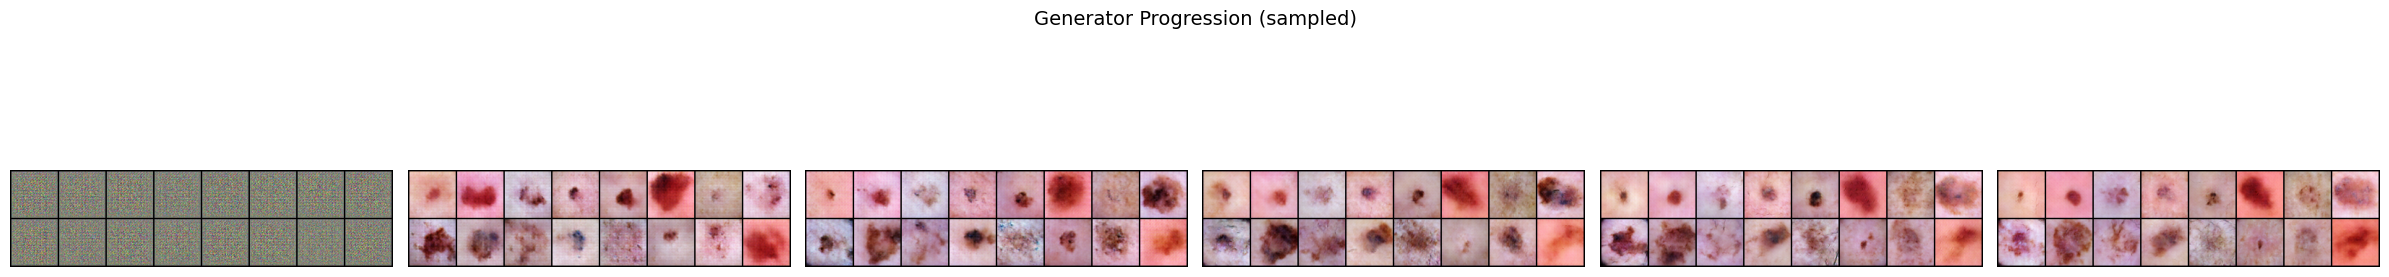

In [36]:
# Show only every 5th grid
step = max(1, len(img_list) // 6)
selected = img_list[::step]

fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4))
if len(selected) == 1:
    axes = [axes]

for idx, img in enumerate(selected):
    axes[idx].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[idx].axis("off")

plt.suptitle("Generator Progression (sampled)", fontsize=14)
plt.tight_layout()
plt.show()

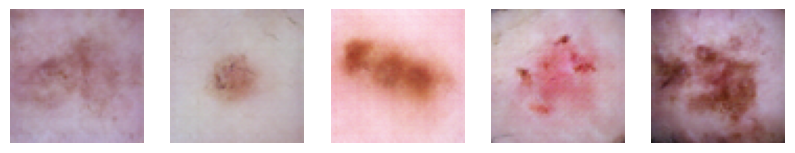

In [35]:
n_samples = 5
fig, axs = plt.subplots(1, n_samples, figsize=(10, 4))

noise_vector = torch.randn(BATCH_SIZE, z, 1, 1, device=DEVICE)
gen_images = gen(noise_vector).detach().cpu()

for j in range(n_samples):
    axs[j].imshow(denormalize(gen_images[j], mean=gan_mean, std=gan_std).squeeze(0).permute(1,2,0))
    axs[j].axis("off")


In [21]:
save_dir = osp.join(repo_path,  r'src/cf_methods/c3lt/weights')

torch.save(gen.state_dict(), osp.join(save_dir, r'generator_derma_4.pth'))
torch.save(discr.state_dict(), osp.join(save_dir, r'discriminator_derma_4.pth'))

## Train AE

In [33]:
class Encoder(nn.Module):
    def __init__(self, latent_dim, ngpu=1, nc=3, ndf=16):
        super(Encoder, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input: (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) x 32 x 32

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) x 16 x 16

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) x 8 x 8

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) x 4 x 4

            nn.Conv2d(ndf * 8, latent_dim, 4, 1, 0, bias=False),
            # (latent_dim) x 1 x 1   ← was 4,2,1 giving 2x2; now 4,1,0 giving 1x1
        )

 
    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output
 
 
class Decoder(nn.Module):
    def __init__(self, latent_dim, ngpu=1, nc=3, ndf=16):
        super(Decoder, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input: (latent_dim) x 2 x 2
            nn.ConvTranspose2d(latent_dim, ndf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) x 4 x 4
 
            nn.ConvTranspose2d(ndf * 8, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) x 8 x 8
 
            nn.ConvTranspose2d(ndf * 4, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) x 16 x 16
 
            nn.ConvTranspose2d(ndf * 2, ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) x 32 x 32
 
            nn.ConvTranspose2d(ndf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
            # (nc) x 64 x 64
        )
 
    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output
 
 
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, latent_dim, nc=3, ndf=16, ngpu=1):
        super(ConvolutionalAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.nc = nc
        self.ndf = ndf
        self.ngpu = ngpu
        self.encoder = Encoder(self.latent_dim, nc=self.nc, ndf=self.ndf)
        self.decoder = Decoder(self.latent_dim, nc=self.nc, ndf=self.ndf)
 
    def forward(self, input):
        output = self.encoder(input)
        output = self.decoder(output)
        return output

In [13]:
ae = ConvolutionalAutoencoder(latent_dim=latent_dim, nc=nc, ndf=ndf, ngpu=1).to(DEVICE)

In [14]:
import torchvision.models as models


class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg

    def forward(self, pred, target):
        # VGG expects 3-channel input normalized with ImageNet stats.
        # If your images are in [-1, 1], rescale to [0, 1] first,
        # then apply ImageNet normalization.
        mean = torch.tensor([0.485, 0.456, 0.406], device=pred.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=pred.device).view(1, 3, 1, 1)

        pred_norm = ((pred + 1) / 2 - mean) / std    # [-1,1] → [0,1] → ImageNet norm
        target_norm = ((target + 1) / 2 - mean) / std

        return nn.functional.mse_loss(self.vgg(pred_norm), self.vgg(target_norm))


mse_loss = nn.MSELoss()
perceptual_loss = PerceptualLoss().to(DEVICE)


def combined_loss(pred, target):
    pixel = mse_loss(pred, target)
    perceptual = perceptual_loss(pred, target)
    return pixel + 0.1 * perceptual


optimizer = torch.optim.Adam(ae.parameters(), lr=0.001)

n_epochs = 40

for epoch in range(1, n_epochs + 1):
    train_loss = 0.0
    ae.train()

    for data in tqdm(train_loader):
        images, _ = data
        images = images.to(DEVICE)

        optimizer.zero_grad()
        outputs = ae(images)
        loss = combined_loss(outputs, images)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    # Divide by total number of samples, not number of batches
    train_loss = train_loss / len(train_loader.dataset)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


100%|██████████| 413/413 [00:16<00:00, 25.34it/s]


Epoch: 1 	Training Loss: 0.713025


100%|██████████| 413/413 [00:16<00:00, 25.78it/s]


Epoch: 2 	Training Loss: 0.572434


...

Epoch: 38 	Training Loss: 0.293025


100%|██████████| 413/413 [00:15<00:00, 26.02it/s]


Epoch: 39 	Training Loss: 0.293044


100%|██████████| 413/413 [00:15<00:00, 25.99it/s]

Epoch: 40 	Training Loss: 0.288616


In [12]:
"""# specify loss function
criterion = nn.MSELoss()

# specify loss function
optimizer = torch.optim.Adam(ae.parameters(), lr=0.001)

# number of epochs to train the model
n_epochs = 30

for epoch in range(1, n_epochs+1):
    # monitor training loss
    train_loss = 0.0
    

    for data in tqdm(train_loader):
        images, _ = data
        images = images.to(DEVICE)

        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        outputs = ae(images)
        loss = criterion(outputs, images)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()*images.size(0)
            
    # print avg training statistics 
    train_loss = train_loss/len(train_loader)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))
"""

100%|██████████| 413/413 [00:05<00:00, 75.57it/s]


Epoch: 1 	Training Loss: 0.567301


100%|██████████| 413/413 [00:04<00:00, 86.81it/s]


Epoch: 2 	Training Loss: 0.228496


100%|██████████| 413/413 [00:04<00:00, 85.91it/s]


...

Epoch: 28 	Training Loss: 0.074196


100%|██████████| 413/413 [00:05<00:00, 80.63it/s]


Epoch: 29 	Training Loss: 0.071112


100%|██████████| 413/413 [00:04<00:00, 85.90it/s]

Epoch: 30 	Training Loss: 0.068764


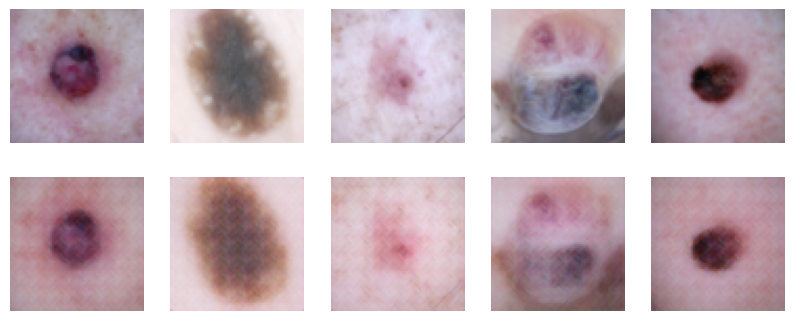

In [15]:
n_samples = 5
fig, axs = plt.subplots(2, n_samples, figsize=(10, 4))

images, _ = next(iter(train_loader))
recon = ae(images.to(DEVICE)).detach().cpu()
# recon_loss = combined_loss(images, recon).item()

for j in range(n_samples):
    axs[0, j].imshow(denormalize(images[j], mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)).squeeze(0).permute(1,2,0))
    axs[0, j].axis("off")
    axs[1, j].imshow(denormalize(recon[j], mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)).squeeze(0).permute(1,2,0))
    axs[1, j].axis("off")

# print(f'Recon loss: {recon_loss:.5f}')


In [41]:
save_dir = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma'
# torch.save(ae.state_dict(), osp.join(save_dir, 'ae_derma_4.pth'))
torch.save(ae.encoder.state_dict(), osp.join(save_dir, 'encoder_derma_4_new.pth'))

In [32]:
gen_weights = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma/gen_epoch_100.pth'
gen = Generator(latent_dim=latent_dim, ngf=ngf, nc=nc).to(DEVICE)

load_model_weights(gen, weights_path=gen_weights)


In [48]:
# Training: encoder → decoder (autoencoder's own decoder)

# Freeze the pretrained generator
gen.eval()
for p in gen.parameters():
    p.requires_grad = False

encoder = Encoder(latent_dim=latent_dim, nc=nc, ndf=ndf).to(DEVICE)
optimizer = torch.optim.Adam(encoder.parameters(), lr=0.001)


def combined_loss(pred, target, percept_coef=0.5):
    pixel = mse_loss(pred, target)
    perceptual = perceptual_loss(pred, target)
    return pixel + percept_coef * perceptual


for epoch in tqdm(range(n_epochs)):
    train_loss = 0
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        
        z = encoder(images)           # encode
        recon = gen(z)                # decode with the GAN's generator
        
        loss = combined_loss(recon, images)  # your MSE + perceptual loss
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        
    train_loss = train_loss/len(train_loader)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))


  0%|          | 0/40 [00:00<?, ?it/s]

  2%|▎         | 1/40 [00:15<09:45, 15.01s/it]

Epoch: 0 	Training Loss: 61.367839


  5%|▌         | 2/40 [00:29<09:26, 14.92s/it]

Epoch: 1 	Training Loss: 57.362166


...

Epoch: 37 	Training Loss: 40.866394


 98%|█████████▊| 39/40 [17:33<00:32, 32.26s/it]

Epoch: 38 	Training Loss: 40.612663


100%|██████████| 40/40 [18:05<00:00, 27.15s/it]

Epoch: 39 	Training Loss: 40.847228


In [47]:
save_dir = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma'
# torch.save(ae.state_dict(), osp.join(save_dir, 'ae_derma_4.pth'))
torch.save(encoder.state_dict(), osp.join(save_dir, 'encoder_derma_4_new2.pth'))

# Evaluate quality

In [16]:
latent_dim = 100
ngf = 64 # Size of feature maps in generator
ndf = 64 # Size of feature maps in discriminator
nc = 3 # Number of channels

In [22]:
gen_weights = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma/gen_epoch_100.pth'
# gen_weights = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/generator_fmnist_0_4.pth'
disc_weights = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma/discr_epoch_100.pth'
# disc_weights = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/discriminator_fmnist_0_4.pth'

# encoder_path = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/derma/encoder_derma_4.pth'

gen = Generator(latent_dim=latent_dim, ngf=ngf, nc=nc).to(DEVICE)
discr = Discriminator(ndf=ndf, nc=nc).to(DEVICE)
# encoder = Encoder(latent_dim=latent_dim, ngpu=1, nc=nc, ndf=ndf)

load_model_weights(gen, weights_path=gen_weights)
load_model_weights(discr, weights_path=disc_weights)
# load_model_weights(encoder, weights_path=encoder_path)

In [49]:
real_images, real_labels = next(iter(test_loader))
real_images.shape

torch.Size([16, 3, 64, 64])

In [50]:
# 1a. Check reconstruction quality
z = encoder(real_images.to(DEVICE))        # batch of real derma images
print(z.shape)
recon = gen(z)
# Save and visually inspect — are these diverse and recognizable?

# 1b. Check generation diversity  
z_random = torch.randn(64, latent_dim, 1, 1).to(DEVICE)
fake = gen(z_random)
# Do these look like diverse skin lesions, or all the same blob?

# 1c. Check latent space spread
z_batch = encoder(real_images.to(DEVICE))  # encode ~500 images
norms = torch.norm(z_batch.view(z_batch.shape[0], -1), dim=1)
print(f"Norm mean: {norms.mean():.3f}, std: {norms.std():.3f}")
# If std is tiny relative to mean, the norm-projection is definitely killing you

torch.Size([16, 100, 1, 1])
Norm mean: 8.874, std: 0.624


In [51]:
recon.shape

torch.Size([16, 3, 64, 64])

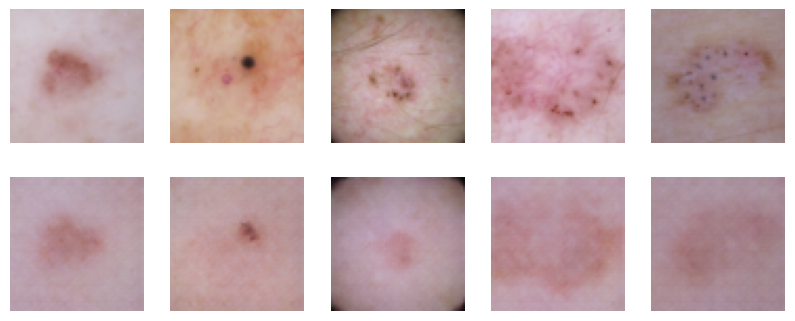

In [52]:
n_samples = 5
fig, axs = plt.subplots(2, n_samples, figsize=(10, 4))

for j in range(n_samples):
    axs[0, j].imshow(denormalize(real_images[j], mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)).squeeze(0).permute(1,2,0))
    axs[0, j].axis("off")
    axs[1, j].imshow(denormalize(recon[j].cpu(), 
                                 mean=(0.5, 0.5, 0.5), 
                                 std=(0.5, 0.5, 0.5)).squeeze(0).permute(1,2,0).detach().numpy())
    axs[1, j].axis("off")

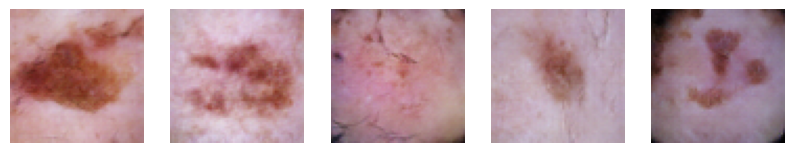

In [37]:
n_samples = 5
fig, ax = plt.subplots(1, n_samples, figsize=(10, 4))

for j in range(n_samples):
    ax[j].imshow(denormalize(fake[j], 
                          mean=(0.5, 0.5, 0.5), 
                          std=(0.5, 0.5, 0.5)).squeeze(0).permute(1,2,0).detach().numpy())
    ax[j].axis("off")

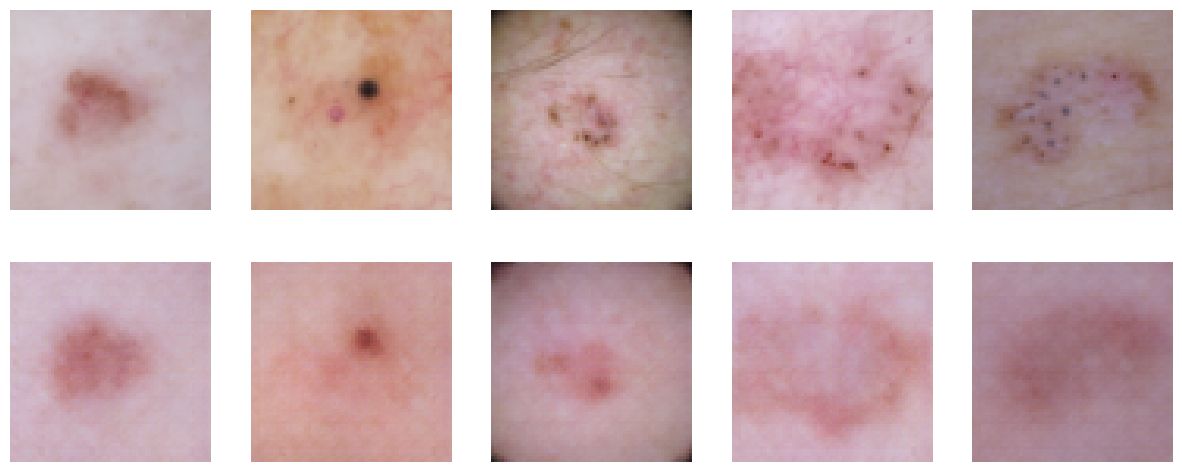

In [43]:
with torch.no_grad():
    z = encoder(real_images[:5].to(DEVICE))
    recon = gen(z)
    
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(5):
        axs[0, i].imshow(((real_images[i].cpu() * 0.5 + 0.5).clamp(0,1)).permute(1,2,0).numpy())
        axs[1, i].imshow(((recon[i].cpu() * 0.5 + 0.5).clamp(0,1)).permute(1,2,0).numpy())
        axs[0, i].axis('off')
        axs[1, i].axis('off')
    plt.show()